# 第078课 Monte Carlo与MCMC
先看解析真值，再看随机误差和失败对照。

In [1]:
from pathlib import Path
import json, numpy as np
from samplers import *
from experiment import run
from IPython.display import display, Image
model=json.loads(Path('data/model.json').read_text())
y=np.array(model['observations'])
m,v=analytic_posterior(y)
print('解析均值/方差/标准差:',m,v,v**.5)

解析均值/方差/标准差: 1.018181818181818 0.12121212121212122 0.3481553119113957


## 独立Monte Carlo与重要性采样

面积估计: {'estimate': 0.32935868415720826, 'exact': 0.3333333333333333, 'se': 0.002089885293879306}
独立后验样本: {'mean': 1.0215111491614457, 'se': 0.0015951731522202619}
重要性采样: {'0.2': {'mean': 0.6044001422981294, 'weight_ess': 27.78632987038769, 'max_weight': 0.09051033670270975}, '2.0': {'mean': 1.0149870212086154, 'weight_ess': 2572.5302487632616, 'max_weight': 0.0005483786310084577}}


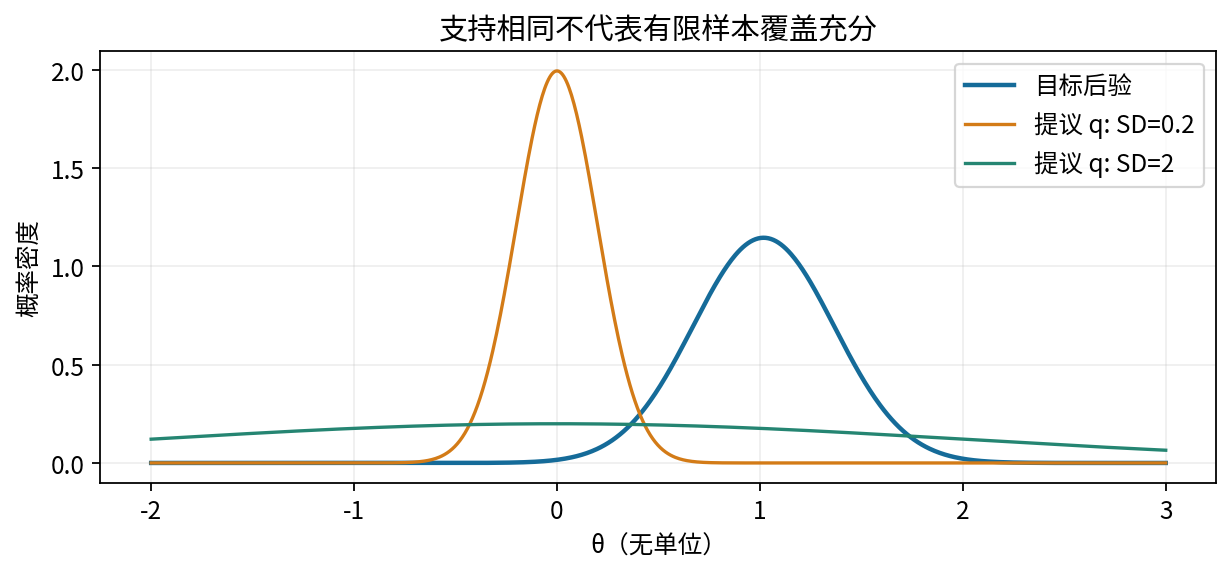

In [2]:
result,chains=run(True)
print('面积估计:',result['monte_carlo_integral'])
print('独立后验样本:',result['iid'])
print('重要性采样:',result['importance_sampling'])
display(Image(filename='figures/02_importance.png'))

## 四链三步长：相同预算，不同探索

tiny {
  "proposal_sd": 0.005,
  "mean": 1.0890816991888181,
  "mean_error": 0.07089988100700007,
  "acceptance": [
    0.9544285714285714,
    0.9806428571428571,
    0.9843571428571428,
    0.9505
  ],
  "ess_per_chain": [
    7.148487998234308,
    7.85208986532243,
    7.050659315117384,
    7.0319983107224004
  ],
  "split_rhat": 6.305172585300555,
  "naive_se": 0.010550955258261475,
  "mcse_heuristic": 0.12363507232167219
}
balanced {
  "proposal_sd": 0.65,
  "mean": 1.021772877608496,
  "mean_error": 0.0035910594266779228,
  "acceptance": [
    0.5235,
    0.531,
    0.522,
    0.5255
  ],
  "ess_per_chain": [
    2490.654012795509,
    2740.9467614286555,
    2656.891930904457,
    2462.75672808137
  ],
  "split_rhat": 1.0002163004943267,
  "naive_se": 0.00157862683967902,
  "mcse_heuristic": 0.0034038363192128405
}
huge {
  "proposal_sd": 12.0,
  "mean": 1.013717534693823,
  "mean_error": -0.004464283487995102,
  "acceptance": [
    0.037714285714285714,
    0.0332857142857142

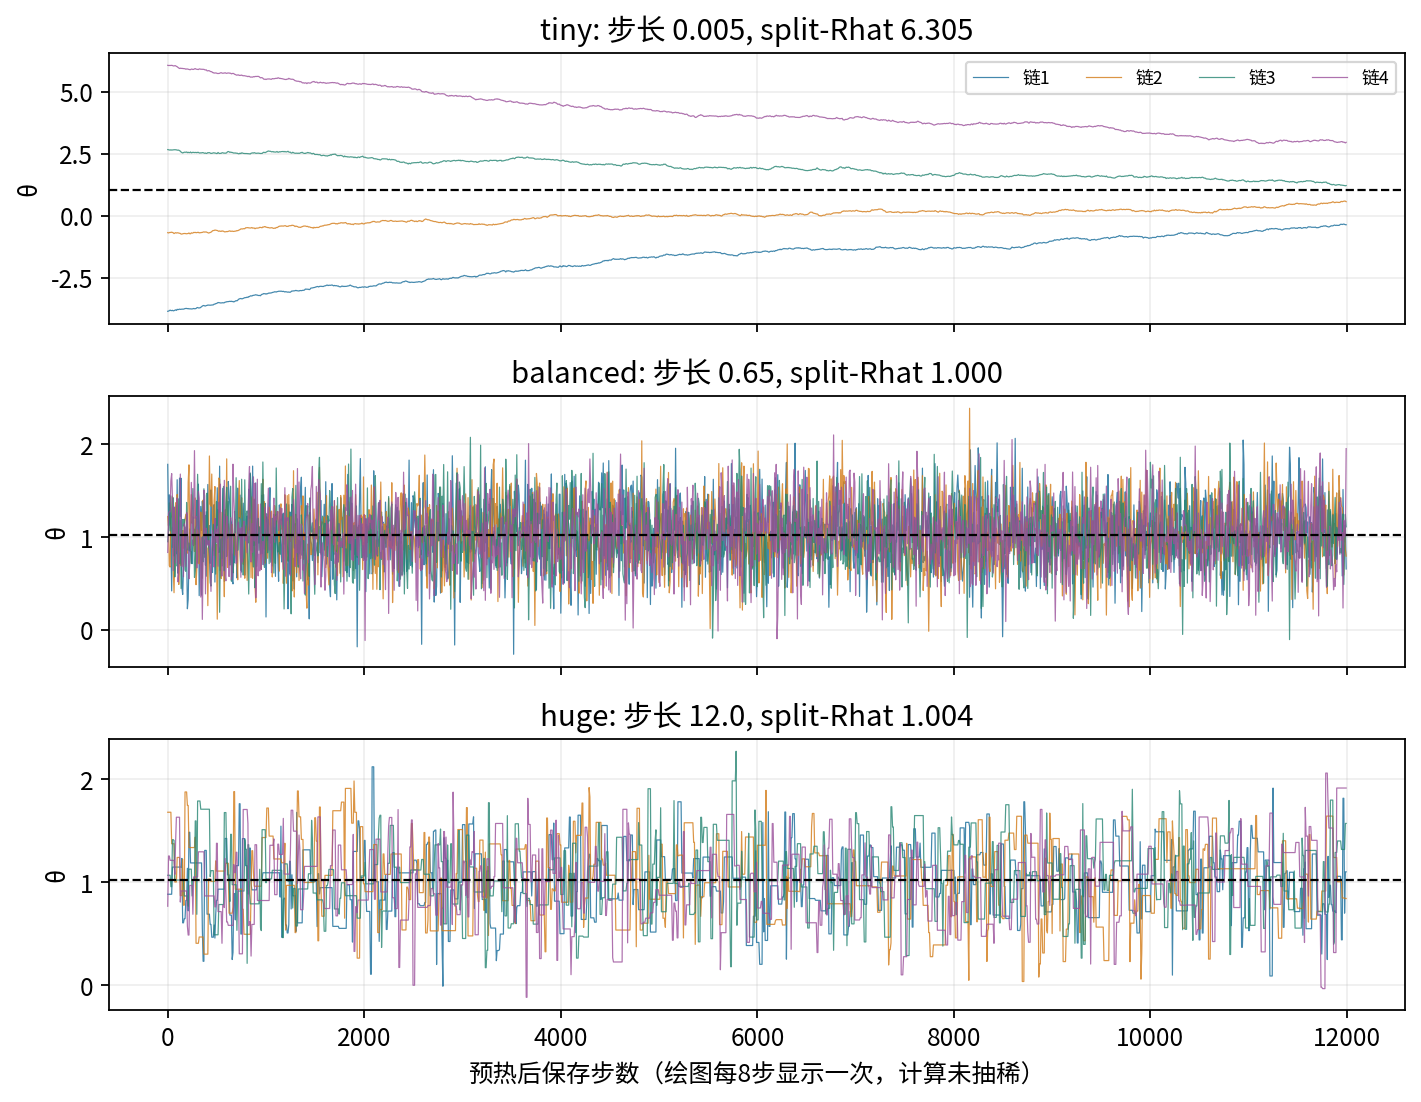

In [3]:
for name,row in result['mh'].items():
    print(name,json.dumps(row,ensure_ascii=False,indent=2))
display(Image(filename='figures/04_trace.png'))

tiny 链1前10个ACF: [1.         0.99965821 0.99931613 0.99897498 0.99863461 0.99829488
 0.99795307 0.9976104  0.9972683  0.99692688 0.99658721]
重复相邻状态比例: 0.03950329194099508
balanced 链1前10个ACF: [1.         0.64193659 0.4229845  0.27932576 0.18640286 0.11879234
 0.07274623 0.04725084 0.02614869 0.01211712 0.00522997]
重复相邻状态比例: 0.4752062671889324
huge 链1前10个ACF: [1.         0.94766807 0.89799094 0.85011866 0.80698099 0.76455331
 0.72464773 0.68784516 0.65096904 0.6162054  0.58590319]
重复相邻状态比例: 0.9628302358529878
注意tiny链不平稳，MCSE没有可靠解释。


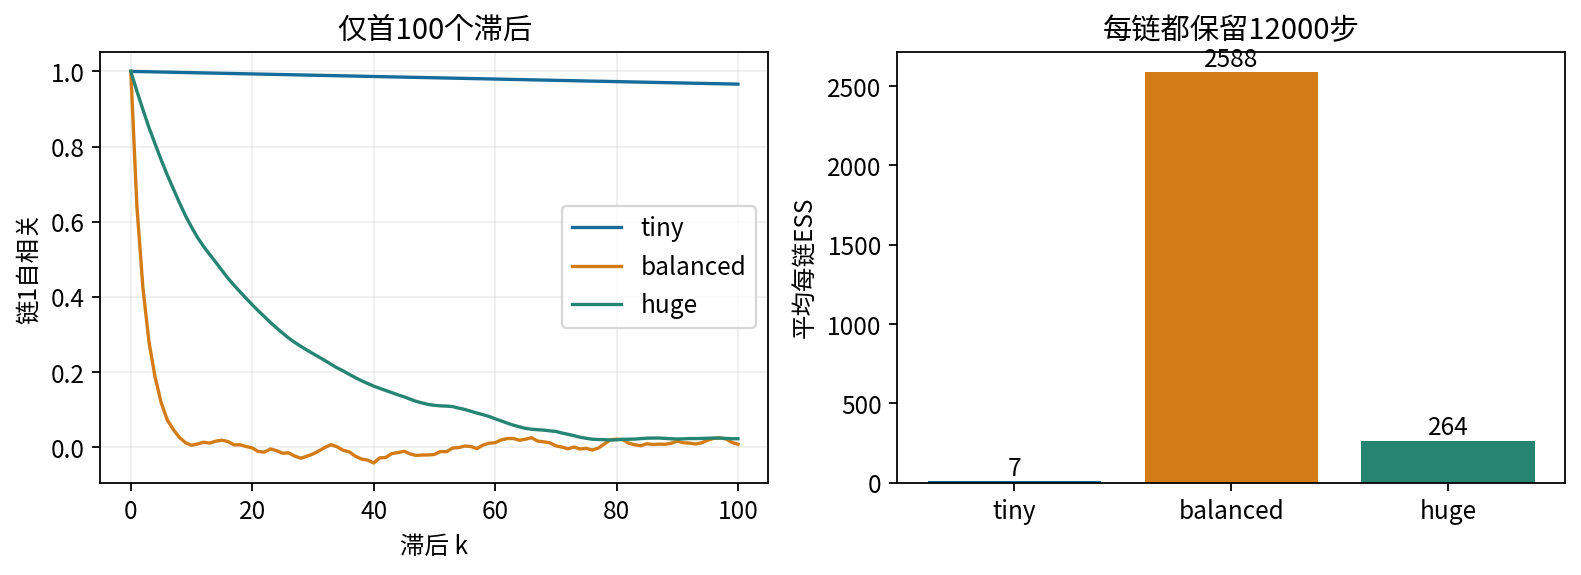

In [4]:
for name,a in chains.items():
    print(name,'链1前10个ACF:',autocorrelation(a[0],10))
    print('重复相邻状态比例:',float(np.mean(np.diff(a[0])==0)))
display(Image(filename='figures/05_diagnostics.png'))
print('注意tiny链不平稳，MCSE没有可靠解释。')

## 条件更新与相关后验的几何

In [5]:
print(json.dumps(result['gibbs'],indent=2))
print('rho=.95条件标准差:',np.sqrt(1-.95**2))
try:
    gibbs_gaussian(1,100,0)
except ValueError as error:
    print('正确拒绝奇异条件:',error)

{
  "0.2": {
    "mean": [
      0.008747257288488878,
      0.007593948597452973
    ],
    "covariance": [
      [
        0.9975953752302896,
        0.19650192220760523
      ],
      [
        0.19650192220760523,
        0.9997255831923226
      ]
    ],
    "ess_x": 18471.28803911432
  },
  "0.95": {
    "mean": [
      0.04290029199109966,
      0.04261785270171672
    ],
    "covariance": [
      [
        0.9799001962804107,
        0.9281859442513328
      ],
      [
        0.9281859442513328,
        0.9767978370996214
      ]
    ],
    "ess_x": 950.651301406913
  }
}
rho=.95条件标准差: 0.31224989991991997
正确拒绝奇异条件: |rho|<1, finite pair start, integer n>=2 required


In [6]:
import unittest
from test_experiment import Checks
r=unittest.TextTestRunner(verbosity=1).run(unittest.defaultTestLoader.loadTestsFromTestCase(Checks))
if not r.wasSuccessful():
    raise RuntimeError('unit tests failed')
print('全部单元测试通过；这不等于所有设置都混合。')

全部单元测试通过；这不等于所有设置都混合。


........
----------------------------------------------------------------------
Ran 8 tests in 2.830s

OK


## 结论
样本数不是有效信息量。比较解析目标、轨迹、相关性与多链诊断，再决定哪些摘要有资格被解释。